# Import Libraries

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset

In [56]:
df = pd.read_csv('nepal_bank_transactions.csv')

# Basic Settings 


In [57]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(9,5)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year_month"]=df["date"].dt.to_period("M").astype(str)
print(df.head(2))

  transaction_id       date      time       branch_name   district  \
0     TXN0000001 2024-01-01  00:43:34     New Baneshwor  Kathmandu   
1     TXN0000002 2024-01-01  01:04:46  Dhangadhi Branch    Kailali   

            channel    transaction_type    card_type account_type  amount_npr  \
0               ATM      Mini Statement  Credit Card      Current         0.0   
1  Internet Banking  Statement Download          NaN      Savings         0.0   

   response_code response_message transaction_status  customer_age  \
0              0         Approved            Success          26.0   
1              0         Approved            Success          30.0   

  customer_gender  processing_time_ms year_month  
0          Female                1322    2024-01  
1             NaN                 711    2024-01  


# Barplot

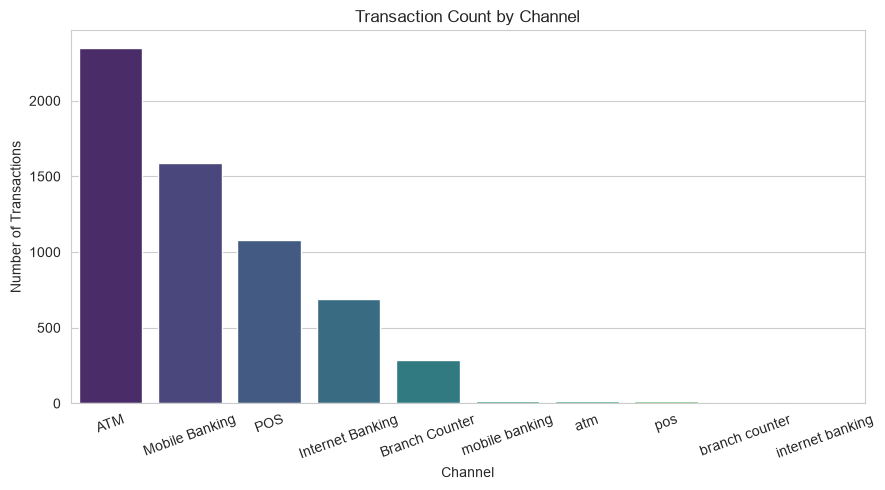

In [58]:
channel_counts = df["channel"].value_counts()
plt.figure()
sns.barplot(x=channel_counts.index, y=channel_counts.values, hue=channel_counts.index, palette= "viridis", legend=False)
plt.title("Transaction Count by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# LineChart 

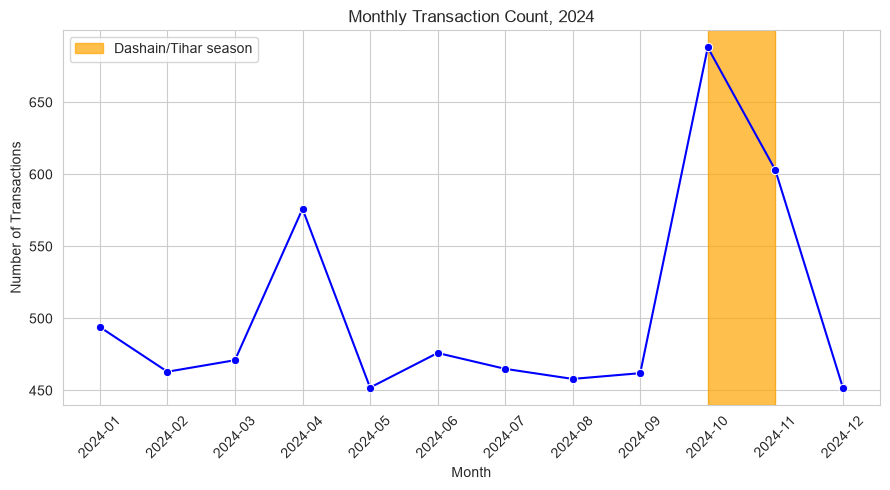

In [59]:
monthly = df.groupby("year_month").size()

plt.figure()
sns.lineplot(x=monthly.index, y=monthly.values, marker="o", color="blue")
plt.title("Monthly Transaction Count, 2024")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.axvspan('2024-10', '2024-11', color='orange', alpha=0.7, label='Dashain/Tihar season')
plt.legend()
plt.tight_layout()
plt.show()

# Histogram(Continuous)

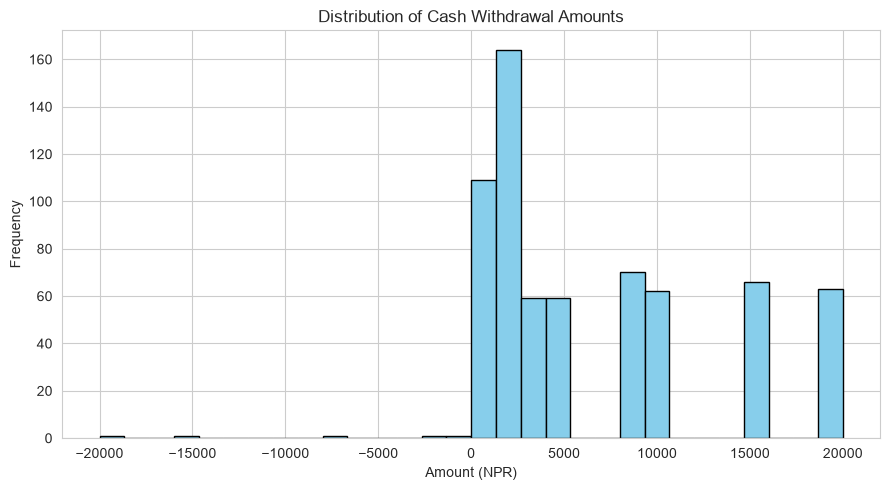

In [60]:
# Amount vary hugely by type
withdrawals = df[df["transaction_type"] == "Cash Withdrawal"]

plt.figure()
plt.hist(withdrawals["amount_npr"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Cash Withdrawal Amounts")
plt.xlabel("Amount (NPR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Boxplot

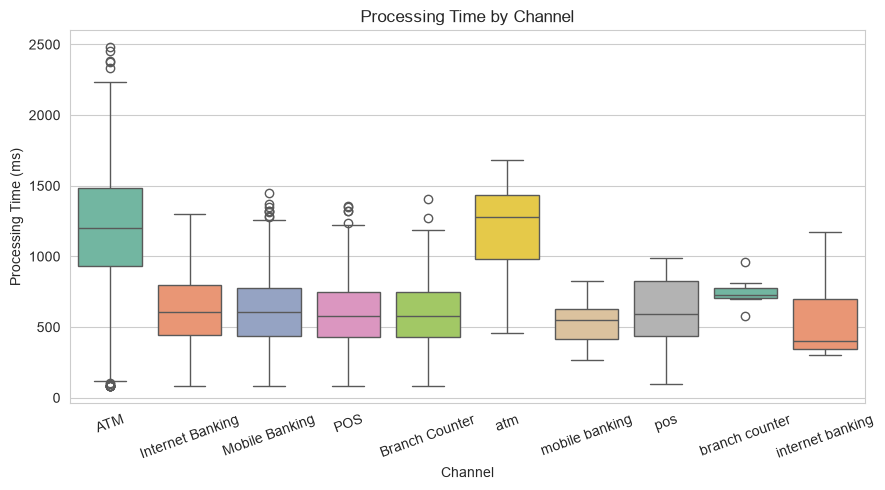

In [61]:
plt.figure()
sns.boxplot(data=df, x="channel", y="processing_time_ms", hue="channel", palette = "Set2", legend=False)
plt.title("Processing Time by Channel")
plt.xlabel("Channel")
plt.ylabel("Processing Time (ms)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Heatmap- channel vs. transaction status

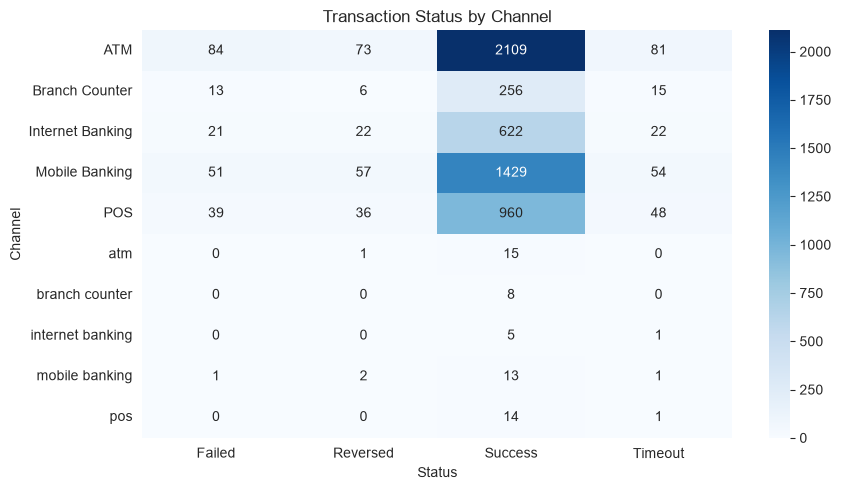

In [62]:
pivot = pd.crosstab(df["channel"], df["transaction_status"])

plt.figure()
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Transaction Status by Channel")
plt.xlabel("Status")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

# Pie Chart

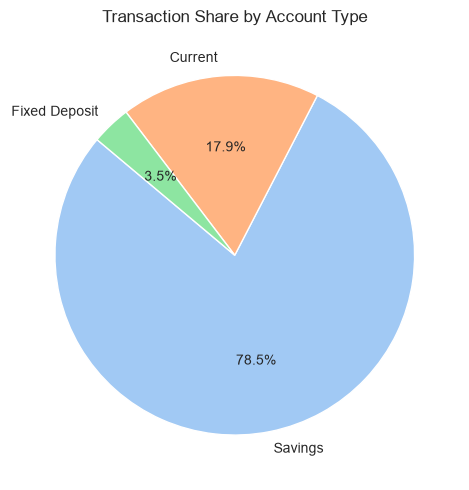

In [63]:
account_counts = df["account_type"].value_counts()
plt.figure()
plt.pie(account_counts.values, labels=account_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Transaction Share by Account Type")
plt.tight_layout()
plt.show()